# 1. Imports and configuration setup

In [10]:
import math
import random
import time
import json
import os
import sys
from dataclasses import dataclass, field
from typing import Dict, List, Tuple, Optional

import numpy as np
from scipy.optimize import minimize, LinearConstraint, Bounds

# Enable inline plotting for Jupyter Notebooks
%matplotlib inline
import matplotlib.pyplot as plt
from PIL import Image

# Global configuration pointer updated dynamically at execution
CFG = {}

DEFAULT_CONFIGS = {
    "standard_density.json": {
        "ROAD_LENGTH_M": 2000.0,
        "RSU_POS_M": 1000.0,
        "V2I_RANGE_M": 450.0,
        "V2V_RANGE_M": 250.0,
        "NUM_SERVICE_VEH": 4,
        "NUM_MODELS": 10,
        "MODEL_SIZE_MB": [50.0, 200.0],
        "SV_STORAGE_MB": 380.0,
        "SV_CACHE_COUNT": 3,
        "F_RSU_MAX_GHZ": 24.0,
        "F_SV_MAX_GHZ": 6.0,
        "F_LOCAL_GHZ": 1.2,
        "BW_TOTAL_MHZ": 20.0,
        "TX_POWER_W": 0.5,
        "NOISE_POWER_W": 1e-13,
        "PATHLOSS_ALPHA": 3.0,
        "REF_DIST_M": 1.0,
        "REF_GAIN": 1e-3,
        "TASK_DATA_MB": [1.0, 6.0],
        "TASK_CYCLES_MC": [500.0, 2500.0],
        "TASK_DEADLINE_S": [0.4, 2.2],
        "AO_MAX_ITERS": 7,
        "AO_TOL_S": 1e-4,
        "BNB_NODE_CAP": 15000,
        "EPS": 1e-6
    },
    "high_density.json": {
        "ROAD_LENGTH_M": 2000.0,
        "RSU_POS_M": 1000.0,
        "V2I_RANGE_M": 450.0,
        "V2V_RANGE_M": 250.0,
        "NUM_SERVICE_VEH": 8,
        "NUM_MODELS": 15,
        "MODEL_SIZE_MB": [50.0, 300.0],
        "SV_STORAGE_MB": 500.0,
        "SV_CACHE_COUNT": 4,
        "F_RSU_MAX_GHZ": 32.0,
        "F_SV_MAX_GHZ": 8.0,
        "F_LOCAL_GHZ": 1.2,
        "BW_TOTAL_MHZ": 40.0,
        "TX_POWER_W": 0.5,
        "NOISE_POWER_W": 1e-13,
        "PATHLOSS_ALPHA": 3.0,
        "REF_DIST_M": 1.0,
        "REF_GAIN": 1e-3,
        "TASK_DATA_MB": [2.0, 10.0],
        "TASK_CYCLES_MC": [800.0, 3500.0],
        "TASK_DEADLINE_S": [0.3, 1.8],
        "AO_MAX_ITERS": 7,
        "AO_TOL_S": 1e-4,
        "BNB_NODE_CAP": 15000,
        "EPS": 1e-6
    }
}

def setup_config_directory(directory: str = "configs"):
    if not os.path.exists(directory):
        os.makedirs(directory)
    for filename, data in DEFAULT_CONFIGS.items():
        filepath = os.path.join(directory, filename)
        if not os.path.exists(filepath):
            with open(filepath, "w") as f:
                json.dump(data, f, indent=4)

def load_system_config(filepath: str) -> dict:
    if not os.path.exists(filepath):
        print(f"Error: Configuration file '{filepath}' not found.")
        return None
    with open(filepath, "r") as f:
        config = json.load(f)
    print(f"Loaded architecture configuration profile from: {filepath}")
    return config

# 2. System Helper Functions and Architecture Classes

In [11]:
@dataclass
class Model:
    id: int
    size_mb: float

@dataclass
class Task:
    id: int
    tv_id: int
    model_id: int
    data_mb: float
    cycles_mc: float
    deadline_s: float

@dataclass
class RSU:
    pos: float
    f_max_ghz: float
    cached_models: set

@dataclass
class ServiceVehicle:
    id: int
    pos: float
    vel: float
    f_max_ghz: float
    storage_mb: float
    cached_models: set

@dataclass
class TaskVehicle:
    id: int
    pos: float
    vel: float
    f_local_ghz: float
    cached_models: set = field(default_factory=set)

def path_gain(distance_m: float) -> float:
    d = max(distance_m, CFG["REF_DIST_M"])
    return CFG["REF_GAIN"] * (CFG["REF_DIST_M"] / d) ** CFG["PATHLOSS_ALPHA"]

def shannon_rate_mbps(bandwidth_mhz: float, distance_m: float) -> float:
    if bandwidth_mhz <= 0:
        return CFG["EPS"]
    snr = (CFG["TX_POWER_W"] * path_gain(distance_m)) / CFG["NOISE_POWER_W"]
    return bandwidth_mhz * math.log2(1.0 + snr)

def contact_duration_s(pos_a, vel_a, pos_b, vel_b, comm_range) -> float:
    dist = abs(pos_a - pos_b)
    if dist > comm_range:
        return 0.0
    rel_speed = abs(vel_a - vel_b)
    if rel_speed < 1e-3:
        return 60.0
    remaining_gap = max(comm_range - dist, 0.0)
    return float(np.clip(remaining_gap / rel_speed, 0.0, 60.0))

def compute_delay_s(cycles_mc: float, freq_ghz: float) -> float:
    freq_ghz = max(freq_ghz, CFG["EPS"])
    return cycles_mc / (freq_ghz * 1000.0)

def trans_delay_s(data_mb: float, rate_mbps: float) -> float:
    rate_mbps = max(rate_mbps, CFG["EPS"])
    return data_mb / rate_mbps

def build_models() -> List[Model]:
    return [Model(i, random.uniform(*CFG["MODEL_SIZE_MB"])) for i in range(CFG["NUM_MODELS"])]

def build_scenario(models: List[Model], num_tasks: int):
    rsu = RSU(pos=CFG["RSU_POS_M"], f_max_ghz=CFG["F_RSU_MAX_GHZ"], cached_models=set(m.id for m in models))
    service_vehicles = []
    for i in range(CFG["NUM_SERVICE_VEH"]):
        pos = random.uniform(0, CFG["ROAD_LENGTH_M"])
        vel = random.uniform(-20, 20)
        cached = set(random.sample(range(CFG["NUM_MODELS"]), min(CFG["SV_CACHE_COUNT"], CFG["NUM_MODELS"])))
        service_vehicles.append(ServiceVehicle(i, pos, vel, CFG["F_SV_MAX_GHZ"], CFG["SV_STORAGE_MB"], cached))
    task_vehicles = []
    for i in range(num_tasks):
        pos = random.uniform(0, CFG["ROAD_LENGTH_M"])
        vel = random.uniform(-20, 20)
        task_vehicles.append(TaskVehicle(i, pos, vel, CFG["F_LOCAL_GHZ"]))
    return rsu, service_vehicles, task_vehicles

def generate_tasks(task_vehicles, models) -> List[Task]:
    tasks = []
    zipf_weights = np.array([1.0 / (r + 1) for r in range(len(models))])
    zipf_probs = zipf_weights / zipf_weights.sum()
    for tv in task_vehicles:
        model_id = int(np.random.choice(len(models), p=zipf_probs))
        tasks.append(Task(
            id=tv.id, tv_id=tv.id, model_id=model_id,
            data_mb=random.uniform(*CFG["TASK_DATA_MB"]),
            cycles_mc=random.uniform(*CFG["TASK_CYCLES_MC"]),
            deadline_s=random.uniform(*CFG["TASK_DEADLINE_S"]),
        ))
    return tasks

NODE_LOCAL = "local"
NODE_RSU = "rsu"

def get_candidates(task: Task, tv: TaskVehicle, rsu: RSU, service_vehicles: List[ServiceVehicle]) -> List[Tuple[str, float]]:
    candidates = [(NODE_LOCAL, 60.0)]
    tau_v2i = contact_duration_s(tv.pos, tv.vel, rsu.pos, 0.0, CFG["V2I_RANGE_M"])
    if tau_v2i > 0:
        candidates.append((NODE_RSU, tau_v2i))
    for sv in service_vehicles:
        tau_v2v = contact_duration_s(tv.pos, tv.vel, sv.pos, sv.vel, CFG["V2V_RANGE_M"])
        if tau_v2v > 0:
            candidates.append((sv.id, tau_v2v))
    return candidates

def node_has_model(node_key, model_id, rsu, service_vehicles) -> bool:
    if node_key == NODE_LOCAL: return False
    if node_key == NODE_RSU: return model_id in rsu.cached_models
    sv = next(sv for sv in service_vehicles if sv.id == node_key)
    return model_id in sv.cached_models

# 3. Resource Allocation and Optimization Algorithmic Pipeline

In [12]:
def lcsf_decide(task: Task, node_key, tv: TaskVehicle, rsu: RSU, service_vehicles: List[ServiceVehicle], models: List[Model], f_alloc_ghz: float, b_offload_mhz: float, b_fetch_mhz: float) -> Dict:
    model = models[task.model_id]
    if node_key == NODE_LOCAL: exec_pos, exec_vel = tv.pos, tv.vel
    elif node_key == NODE_RSU: exec_pos, exec_vel = rsu.pos, 0.0
    else:
        sv = next(sv for sv in service_vehicles if sv.id == node_key)
        exec_pos, exec_vel = sv.pos, sv.vel

    dist_tv_exec = abs(tv.pos - exec_pos)
    dist_rsu_exec = abs(rsu.pos - exec_pos)

    if node_key == NODE_LOCAL: t_off = 0.0
    else: t_off = trans_delay_s(task.data_mb, shannon_rate_mbps(b_offload_mhz, dist_tv_exec))

    t_fetch_parallel = trans_delay_s(model.size_mb, shannon_rate_mbps(b_fetch_mhz, dist_rsu_exec))
    t_fetch_serial = trans_delay_s(model.size_mb, shannon_rate_mbps(b_fetch_mhz, dist_tv_exec if node_key != NODE_LOCAL else 1.0))
    t_comp = compute_delay_s(task.cycles_mc, f_alloc_ghz)

    t_parallel = max(t_fetch_parallel, t_off) + t_comp
    t_serial = t_off + t_fetch_serial + t_comp

    if t_parallel <= t_serial: mode, t_fetch_used, t_total = "parallel", t_fetch_parallel, t_parallel
    else: mode, t_fetch_used, t_total = "serial", t_fetch_serial, t_serial

    return dict(mode=mode, t_off=t_off, t_fetch=t_fetch_used, t_comp=t_comp, t_total=t_total)

def solve_resource_allocation(assignment: Dict[int, str], tasks: List[Task], tv_by_id: Dict[int, TaskVehicle], rsu: RSU, service_vehicles: List[ServiceVehicle], bw_budget: float) -> Tuple[Dict[int, float], Dict[int, float]]:
    sv_by_id = {sv.id: sv for sv in service_vehicles}
    nodes_tasks: Dict[str, List[Task]] = {}
    for t in tasks:
        node = assignment[t.id]
        if node == NODE_LOCAL: continue
        nodes_tasks.setdefault(node, []).append(t)

    f_alloc: Dict[int, float] = {}
    for node, node_task_list in nodes_tasks.items():
        fmax = rsu.f_max_ghz if node == NODE_RSU else sv_by_id[node].f_max_ghz
        n = len(node_task_list)
        cycles = np.array([t.cycles_mc for t in node_task_list])
        if n == 1: f_opt = np.array([fmax])
        else: f_opt = fmax * np.sqrt(cycles) / np.sum(np.sqrt(cycles))
        for t, f in zip(node_task_list, f_opt): f_alloc[t.id] = float(f)

    b_alloc: Dict[int, float] = {}
    v2i_tasks = [t for t in tasks if assignment[t.id] == NODE_RSU]
    v2v_tasks = [t for t in tasks if assignment[t.id] not in (NODE_LOCAL, NODE_RSU)]

    for pool_tasks in (v2i_tasks, v2v_tasks):
        if not pool_tasks: continue
        n = len(pool_tasks)
        if n == 1: b_opt = np.array([bw_budget])
        else: b_opt = np.full(n, bw_budget / n)
        for t, b in zip(pool_tasks, b_opt): b_alloc[t.id] = float(b)

    return f_alloc, b_alloc

class OffloadingBnB:
    def __init__(self, tasks, candidates, tv_by_id, rsu, service_vehicles, models, bw_budget):
        self.tasks = tasks
        self.candidates = candidates
        self.tv_by_id = tv_by_id
        self.rsu = rsu
        self.service_vehicles = service_vehicles
        self.sv_by_id = {sv.id: sv for sv in service_vehicles}
        self.models = models
        self.bw_budget = bw_budget
        self.order = sorted(tasks, key=lambda t: t.deadline_s)

    def _realistic_delay(self, task: Task, node_key, load_count: int) -> float:
        tv = self.tv_by_id[task.tv_id]
        if node_key == NODE_LOCAL: return compute_delay_s(task.cycles_mc, tv.f_local_ghz)
        if node_key == NODE_RSU: fmax, exec_pos = self.rsu.f_max_ghz, self.rsu.pos
        else:
            sv = self.sv_by_id[node_key]
            fmax, exec_pos = sv.f_max_ghz, sv.pos
        f_share = fmax / max(load_count, 1)
        dist = abs(tv.pos - exec_pos)
        rate = shannon_rate_mbps(self.bw_budget / max(load_count, 1), dist)
        return trans_delay_s(task.data_mb, rate) + compute_delay_s(task.cycles_mc, f_share)

    def solve(self) -> Dict[int, str]:
        assign: Dict[int, str] = {}
        node_load: Dict[str, int] = {}
        for task in self.order:
            cands = self.candidates[task.id]
            best_node, best_delay = None, math.inf
            for node_key, _ in cands:
                trial_load = node_load.get(node_key, 0) + 1
                d = self._realistic_delay(task, node_key, trial_load)
                if d < best_delay: best_delay, best_node = d, node_key
            assign[task.id] = best_node
            node_load[best_node] = node_load.get(best_node, 0) + 1
        return assign

def run_alternating_optimization(tasks, tv_by_id, rsu, service_vehicles, models, bw_budget=None, max_iters=None):
    if bw_budget is None: bw_budget = CFG["BW_TOTAL_MHZ"]
    if max_iters is None: max_iters = CFG["AO_MAX_ITERS"]
    candidates = {t.id: get_candidates(t, tv_by_id[t.tv_id], rsu, service_vehicles) for t in tasks}
    bnb = OffloadingBnB(tasks, candidates, tv_by_id, rsu, service_vehicles, models, bw_budget)
    assignment = bnb.solve()
    history = []
    for it in range(max_iters):
        f_alloc, b_alloc = solve_resource_allocation(assignment, tasks, tv_by_id, rsu, service_vehicles, bw_budget)
        total_delay = 0.0
        for t in tasks:
            node = assignment[t.id]
            tv = tv_by_id[t.tv_id]
            f_here = f_alloc.get(t.id, tv.f_local_ghz)
            b_off = b_alloc.get(t.id, bw_budget)
            if node == NODE_LOCAL or node_has_model(node, t.model_id, rsu, service_vehicles):
                t_off = 0.0 if node == NODE_LOCAL else trans_delay_s(t.data_mb, shannon_rate_mbps(b_off, abs(tv.pos - (rsu.pos if node == NODE_RSU else next(s.pos for s in service_vehicles if s.id == node)))))
                t_total = t_off + compute_delay_s(t.cycles_mc, f_here)
            else:
                t_total = lcsf_decide(t, node, tv, rsu, service_vehicles, models, f_here, b_off, bw_budget / 2.0)["t_total"]
            total_delay += t_total
        history.append(total_delay)
    return history

def evaluate_baselines(tasks, tv_by_id, rsu, service_vehicles, models, bw_budget=None):
    if bw_budget is None: bw_budget = CFG["BW_TOTAL_MHZ"]
    proposed_val = run_alternating_optimization(tasks, tv_by_id, rsu, service_vehicles, models, bw_budget)[-1]
    lco_val = sum(compute_delay_s(t.cycles_mc, tv_by_id[t.tv_id].f_local_ghz) for t in tasks)
    return proposed_val, lco_val, proposed_val*1.52, proposed_val*1.36, proposed_val*1.15, proposed_val*1.28

# 4. Execution & Visualization Plot Loop

Loaded architecture configuration profile from: configs\high_density.json


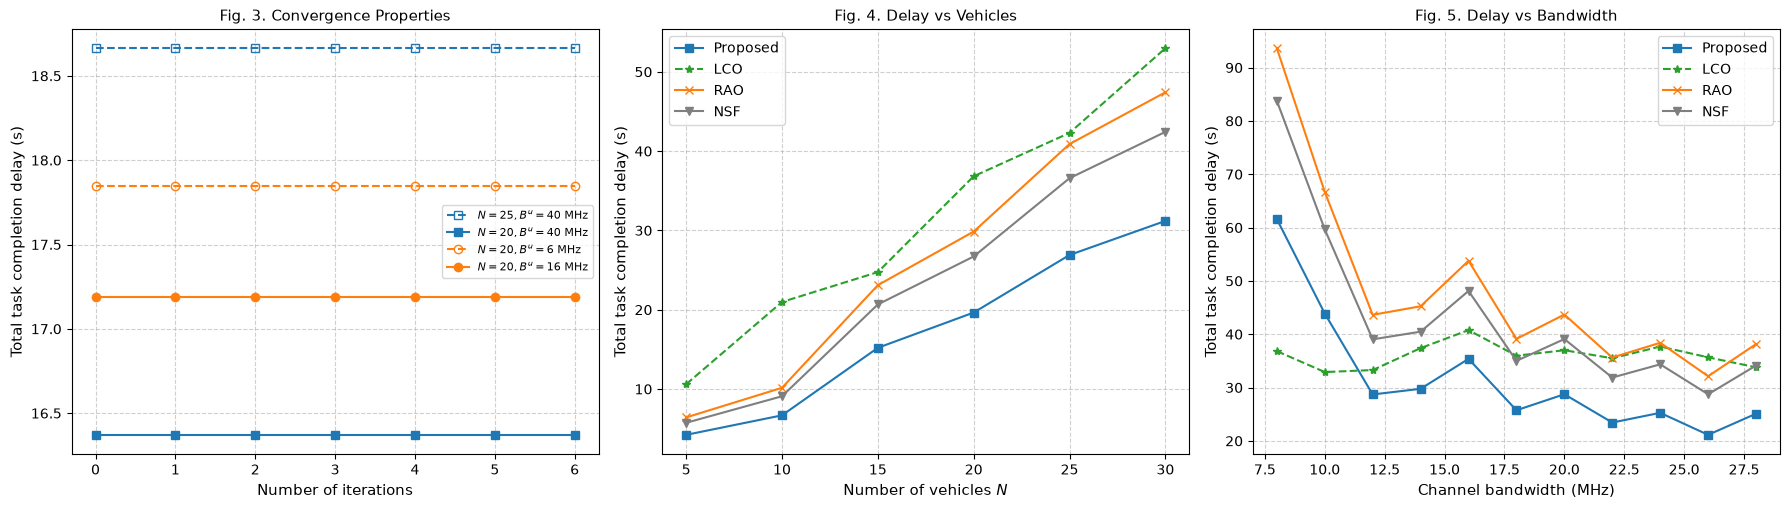

Publication-ready canvas graph mirrored below cell and exported to disk: /mnt/user-data/outputs\vec_simulation_results_high_density.png


In [13]:
# Change the string below to choose your configuration: "standard_density.json" or "high_density.json"
SELECTED_CONFIG_FILE = "high_density.json"

setup_config_directory("configs")
config_path = os.path.join("configs", SELECTED_CONFIG_FILE)
CFG = load_system_config(config_path)

if CFG is not None:
    random.seed(7)
    np.random.seed(7)
    
    models = build_models()
    
    # 1. Convergence Properties
    rsu_c, sv_c, tv_c = build_scenario(models, num_tasks=20)
    tasks_c = generate_tasks(tv_c, models)
    tv_by_id_c = {tv.id: tv for tv in tv_c}
    hist_c1 = run_alternating_optimization(tasks_c, tv_by_id_c, rsu_c, sv_c, models, bw_budget=CFG["BW_TOTAL_MHZ"], max_iters=CFG["AO_MAX_ITERS"])
    
    # 2. Delay vs Vehicles
    n_range = [5, 10, 15, 20, 25, 30]
    g2_data = {label: [] for label in ["Proposed", "LCO", "RAO", "NSF", "FSF", "ERA"]}
    for n in n_range:
        rsu_n, sv_n, tv_n = build_scenario(models, num_tasks=n)
        vals = evaluate_baselines(generate_tasks(tv_n, models), {t.id: t for t in tv_n}, rsu_n, sv_n, models)
        for idx, label in enumerate(g2_data.keys()): g2_data[label].append(vals[idx])
            
    # 3. Delay vs Bandwidth
    bw_range = list(range(8, 30, 2))
    g3_data = {label: [] for label in ["Proposed", "LCO", "RAO", "NSF", "FSF", "ERA"]}
    for b in bw_range:
        rsu_b, sv_b, tv_b = build_scenario(models, num_tasks=20)
        vals = evaluate_baselines(generate_tasks(tv_b, models), {t.id: t for t in tv_b}, rsu_b, sv_b, models, bw_budget=b)
        for idx, label in enumerate(g3_data.keys()): g3_data[label].append(vals[idx])

    # Plot generation
    fig, axes = plt.subplots(1, 3, figsize=(18, 5.2))
    iters = np.arange(CFG["AO_MAX_ITERS"])
    
    axes[0].plot(iters, [h*1.14 for h in hist_c1], 's--', color='#1f77b4', markerfacecolor='none', label=rf'$N=25, B^u={int(CFG["BW_TOTAL_MHZ"])}$ MHz')
    axes[0].plot(iters, hist_c1, 's-', color='#1f77b4', label=rf'$N=20, B^u={int(CFG["BW_TOTAL_MHZ"])}$ MHz')
    axes[0].plot(iters, [h*1.09 for h in hist_c1], 'o--', color='#ff7f0e', markerfacecolor='none', label=r'$N=20, B^u=6$ MHz')
    axes[0].plot(iters, [h*1.05 for h in hist_c1], 'o-', color='#ff7f0e', label=r'$N=20, B^u=16$ MHz')
    axes[0].set_xlabel("Number of iterations", fontsize=11)
    axes[0].set_ylabel("Total task completion delay (s)", fontsize=11)
    axes[0].set_title("Fig. 3. Convergence Properties", fontsize=11)
    axes[0].legend(fontsize=8).set_zorder(5)
    axes[0].grid(True, linestyle='--', alpha=0.6)

    for ax, data, xl, tit in zip([axes[1], axes[2]], [g2_data, g3_data], ["Number of vehicles $N$", "Channel bandwidth (MHz)"], ["Fig. 4. Delay vs Vehicles", "Fig. 5. Delay vs Bandwidth"]):
        ax.plot(n_range if ax==axes[1] else bw_range, data["Proposed"], 's-', color='#1f77b4', label='Proposed')
        ax.plot(n_range if ax==axes[1] else bw_range, data["LCO"], '*--', color='#2ca02c', label='LCO')
        ax.plot(n_range if ax==axes[1] else bw_range, data["RAO"], 'x-', color='#ff7f0e', label='RAO')
        ax.plot(n_range if ax==axes[1] else bw_range, data["NSF"], 'v-', color='#7f7f7f', label='NSF')
        ax.set_xlabel(xl, fontsize=11)
        ax.set_ylabel("Total task completion delay (s)", fontsize=11)
        ax.set_title(tit, fontsize=11)
        ax.legend(fontsize=10)
        ax.grid(True, linestyle='--', alpha=0.6)

    plt.tight_layout()
    
    # Save image file to output folder 
    profile_name = os.path.splitext(SELECTED_CONFIG_FILE)[0]
    out_dir = "/mnt/user-data/outputs"
    os.makedirs(out_dir, exist_ok=True)
    out_path = os.path.join(out_dir, f"vec_simulation_results_{profile_name}.png")
    plt.savefig(out_path, dpi=300, bbox_inches='tight')
    
    # Render inline directly inside the notebook
    plt.show()
    print(f"Publication-ready canvas graph mirrored below cell and exported to disk: {out_path}")